In [120]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [121]:
# create a model class that inherits nn.Module
class Model(nn.Module):
  # __init__ is the constructor of the class, it initializes the layers of the neural network.
  # in_features: The number of input features.
  # h1: The number of neurons in the first hidden layer.
  # h2: The number of neurons in the second hidden layer.
  # out_features: The number of output features.
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    # super().__init__() calls the constructor of the parent class (nn.Module).
    super().__init__()
    # self.fc1 defines the first "fully connected(fc)" (linear) layer.
    # It takes in_features as input and outputs h1 features.
    self.fc1 = nn.Linear(in_features, h1)
    # self.fc2 defines the second fully connected layer.
    # It takes h1 features as input and outputs h2 features.
    self.fc2 = nn.Linear(h1, h2)
    # self.out defines the output layer.
    # It takes h2 features as input and outputs out_features features.
    self.out = nn.Linear(h2, out_features)

  # forward defines the forward pass of the neural network.
  # It specifies how the input data x flows through the layers.
  def forward(self, x):
    # The input x is passed through the first linear layer (self.fc1),
    # and then the ReLU activation function (F.relu) is applied.
    x = F.relu(self.fc1(x))
    # The output of the first hidden layer is passed through the second linear layer (self.fc2),
    # followed by the ReLU activation function.
    x= F.relu(self.fc2(x))
    # The output of the second hidden layer is passed through the output layer (self.out).
    x = self.out(x)
    # The final output of the network is returned.
    return x

In [122]:
torch.manual_seed(41)
''' is used to set the seed for the random number generator in PyTorch. This is important for reproducibility. By setting a seed, you ensure that any operation involving randomness (like initializing weights in a neural network) will produce the same results every time you run the code. The number 41 is an arbitrary integer used as the seed value.'''

model=Model()

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
%matplotlib inline

In [124]:
df=pd.read_csv("Iris.csv")
df.drop(columns="Id",inplace=True)

In [125]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [126]:
df["Species"] = df["Species"].replace("Iris-setosa",0.0)
df["Species"] = df["Species"].replace("Iris-versicolor",1.0)
df["Species"] = df["Species"].replace("Iris-virginica",2.0)
df.head()


/tmp/ipython-input-2640913146.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Species"] = df["Species"].replace("Iris-virginica",2.0)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [127]:
X=df.drop("Species",axis=1).values
y=df["Species"].values

In [128]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [129]:
# Convert the training and testing data from NumPy arrays to PyTorch tensors.
# PyTorch models and operations work with tensors.

# Convert the training features (X_train) to a PyTorch FloatTensor.
# FloatTensor is used for numerical data.
X_train = torch.FloatTensor(X_train)

# Convert the testing features (X_test) to a PyTorch FloatTensor.
# FloatTensor is used for numerical data.
X_test = torch.FloatTensor(X_test)

# Convert the training labels (y_train) to a PyTorch LongTensor.
# LongTensor is typically used for integer-based data like labels or indices.
y_train = torch.LongTensor(y_train)

# Convert the testing labels (y_test) to a PyTorch LongTensor.
# LongTensor is typically used for integer-based data like labels or indices.
y_test = torch.LongTensor(y_test)

In [130]:
# Define the loss function
# nn.CrossEntropyLoss() is commonly used for classification problems with multiple classes.it is used o calculate loss function
criterion=nn.CrossEntropyLoss()

# Define the optimizer
# torch.optim.Adam is a popular optimization algorithm.
# model.parameters() tells the optimizer which parameters to update.
# lr is the learning rate, which controls the step size during parameter updates.
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [131]:
# Set the number of training epochs
epochs=100
# Initialize an empty list to store loss values
losses=[]
# Loop through the specified number of epochs
for i in range(epochs):
  # Perform the forward pass: get predictions from the model
  y_pred=model.forward(X_train)
  # Calculate the loss between predictions and actual training labels
  loss=criterion(y_pred,y_train)
  # Append the loss value (as a NumPy array) to the losses list
  losses.append(loss.detach().numpy())
  # Print the epoch number and loss every 10 epochs
  if i%10==0:
    print(f"Epoch:{i} Loss:{loss}")
  # Zero out the gradients before backpropagation
  optimizer.zero_grad()
  # Perform backpropagation: calculate gradients of the loss with respect to model parameters
  loss.backward()
  # Update the model's parameters using the optimizer
  optimizer.step()

Epoch:0 Loss:1.1251550912857056
Epoch:10 Loss:1.0096259117126465
Epoch:20 Loss:0.8157405853271484
Epoch:30 Loss:0.585706353187561
Epoch:40 Loss:0.3999636471271515
Epoch:50 Loss:0.26768800616264343
Epoch:60 Loss:0.17942361533641815
Epoch:70 Loss:0.12151690572500229
Epoch:80 Loss:0.0860118493437767
Epoch:90 Loss:0.06520850956439972


Text(0.5, 0, 'Epochs')

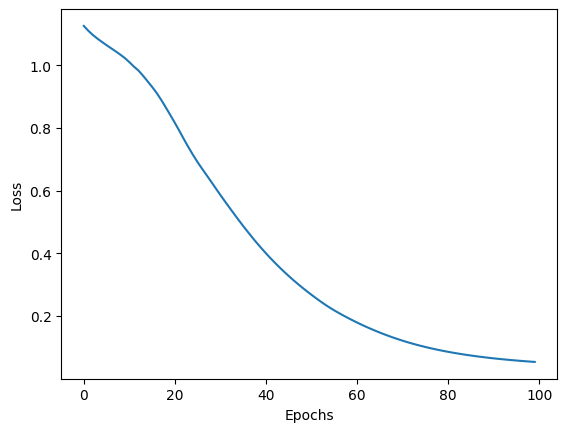

In [132]:
plt.plot(range(epochs),losses)
plt.ylabel("Loss")
plt.xlabel("Epochs")
